# Feature analysis: time trends

## Question

---

Is demand stable over time, or is there a trend between 2011 and 2012?
If there is a trend — do we need a `year` feature (or something instead of it)?

This is a basic check of temporal stability: if the demand level shifts a lot
year over year, a model without a time feature will be systematically wrong,
and the train/test split over time must be chosen deliberately.

> **Data discipline.** Descriptive analysis over the full 2011–2012 period — to understand the process.
> The findings are structural (growth, regimes, weekly shape — they hold on train too). Feature and model selection happens on validation
> in [eda_and_modeling.ipynb](eda_and_modeling.ipynb); test stays untouched until the end. Using the full period here is not leakage but data completeness: year-over-year growth and seasonality are only visible across both years.

## Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PROCESSED = Path("../data/processed")

# Start from the week-2 base dataset (asset hourly_by_location, single source of truth), not rebuilding from raw.
fd = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])
fd["date"] = fd["datetime_hourly"].dt.normalize()

## Daily aggregation

---

We sum rentals per day. Holidays are flagged so the trend can be viewed on regular days
(holidays are separate dips/spikes that distort the base level).

In [3]:
# Daily aggregate: total rentals per date (over all locations) + holiday flag.
daily = fd.groupby("date").agg(
    daily_rentals=("total_rentals", "sum"),
    is_holiday=("is_holiday", "max"),
).reset_index()
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["day_of_week"] = daily["date"].dt.dayofweek

regular = daily[daily["is_holiday"] == 0]

print(f"Total days: {len(daily)} (regular: {len(regular)}, holidays: {daily['is_holiday'].sum()})")

Total days: 731 (regular: 710, holidays: 21)


## 1. Demand over time

---

A monthly time series over two years — can we see a trend and seasonality visually?

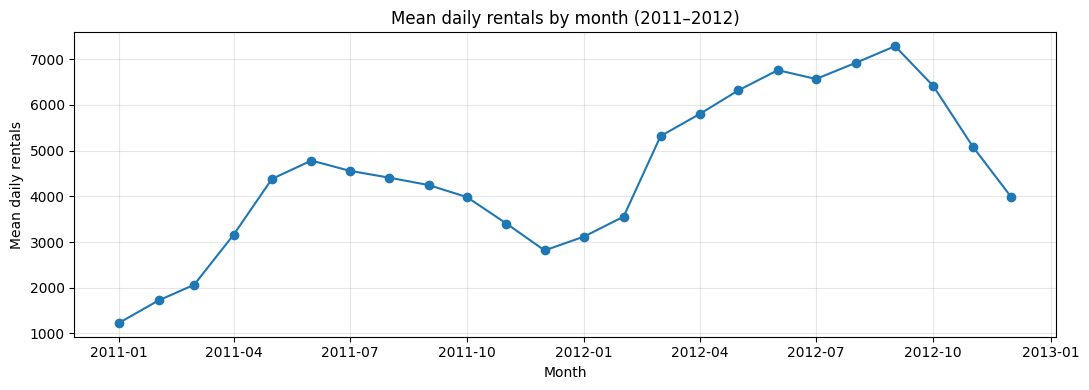

In [4]:
monthly = daily.groupby(["year", "month"])["daily_rentals"].mean().reset_index()
monthly["period"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str) + "-01"
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly["period"], monthly["daily_rentals"], marker="o")
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily rentals")
ax.set_title("Mean daily rentals by month (2011–2012)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observations

- Clear within-year seasonality: demand is higher in summer and lower in winter.
- The 2012 level is noticeably above 2011 across the whole series — there is an upward trend. Quantified in §2.

## 2. Year-over-year growth

---

We measure growth on regular days (without holidays, so the base level is not distorted).
If growth is uniform across months, it is organic service growth, not a seasonal artefact.

In [5]:
year_stats = regular.groupby("year")["daily_rentals"].agg(["mean", "median"]).round(0)
growth_pct = (year_stats.loc[2012, "mean"] / year_stats.loc[2011, "mean"] - 1) * 100

print("Mean rentals by year (regular days):")
print(year_stats)
print(f"\nGrowth 2012 vs 2011: +{growth_pct:.0f}%")

Mean rentals by year (regular days):
        mean  median
year                
2011  3417.0  3747.0
2012  5637.0  5936.0

Growth 2012 vs 2011: +65%


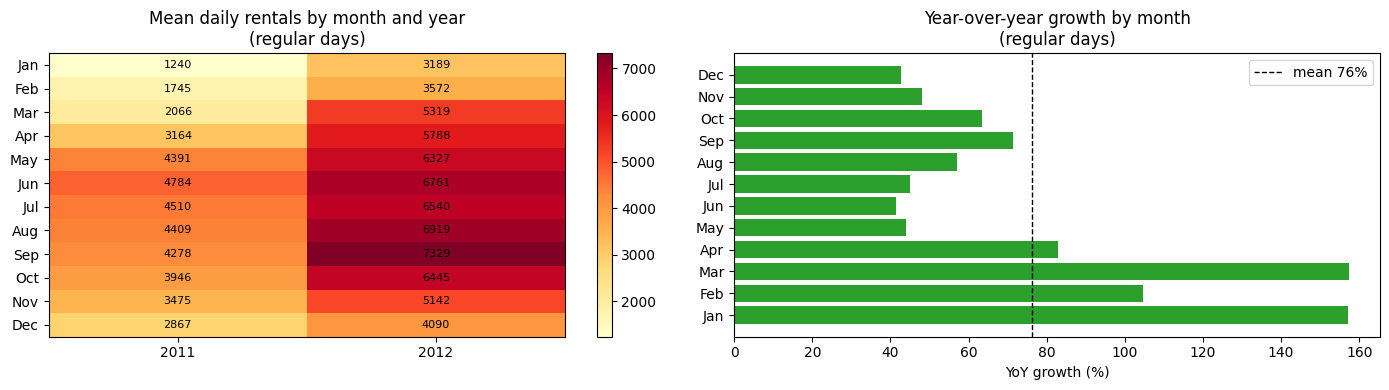

In [6]:
pivot = regular.groupby(["year", "month"])["daily_rentals"].mean().unstack("year").round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(pivot.values, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["2011", "2012"])
axes[0].set_yticks(range(12))
axes[0].set_yticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
for i in range(12):
    for j in range(2):
        axes[0].text(j, i, f"{pivot.values[i, j]:.0f}", ha="center", va="center", fontsize=8)
axes[0].set_title("Mean daily rentals by month and year\n(regular days)")
plt.colorbar(im, ax=axes[0])

growth = ((pivot[2012] / pivot[2011]) - 1) * 100
axes[1].barh(range(12), growth.values, color="#2ca02c")
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
axes[1].set_xlabel("YoY growth (%)")
axes[1].set_title("Year-over-year growth by month\n(regular days)")
axes[1].axvline(growth.mean(), color="black", linestyle="--", linewidth=1,
                label=f"mean {growth.mean():.0f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

### Observations

- 2012 is on average **+65%** above 2011 on regular days.
- Growth is positive **in every month** without exception → a real level shift, not a seasonal artefact. But it is uneven (January +157%, July +45%): early 2011 starts from a low launch base — we separate this in §3.
- The level is unstable over time: a model without a time feature will systematically underestimate 2012.

## 3. Two regimes: launch vs organic

---

The +65% growth is uneven across months (January +157%, July +45%) — a low-base effect:
in early 2011 the service was just starting almost from zero. We separate the **launch phase**
from the **organic regime** so trend and seasonality are not mixed with one-time adoption.

Method: a seasonal index (monthly mean ÷ yearly mean) for each year.
In 2012 (mature all year) the index is the pure seasonal shape. Where the 2011 index
catches up with 2012, the launch phase ends.

In [7]:
# Seasonal index = monthly mean / yearly mean. In 2012 this is pure seasonality
# (the year is mature throughout). In 2011 the early months are also depressed by adoption → lower index.
season_idx = pivot / pivot.mean()
yoy = ((pivot[2012] / pivot[2011]) - 1) * 100

# Boundary: while the 2011 index stays below 2012 (adoption deficit) from the start of the year — that is launch.
boundary = 0
for m in range(1, 13):
    if season_idx.loc[m, 2011] < season_idx.loc[m, 2012]:
        boundary = m
    else:
        break

tbl = pd.DataFrame({
    "index_2011": season_idx[2011].round(2),
    "index_2012": season_idx[2012].round(2),
    "YoY_%": yoy.round(0),
})
tbl.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
             "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
print(tbl.to_string())
print(f"\nLaunch phase: 2011, months 1..{boundary}. Organic regime: from 2011-{boundary + 1:02d}.")

     index_2011  index_2012  YoY_%
Jan        0.36        0.57  157.0
Feb        0.51        0.64  105.0
Mar        0.61        0.95  157.0
Apr        0.93        1.03   83.0
May        1.29        1.13   44.0
Jun        1.40        1.20   41.0
Jul        1.32        1.16   45.0
Aug        1.29        1.23   57.0
Sep        1.26        1.30   71.0
Oct        1.16        1.15   63.0
Nov        1.02        0.92   48.0
Dec        0.84        0.73   43.0

Launch phase: 2011, months 1..4. Organic regime: from 2011-05.


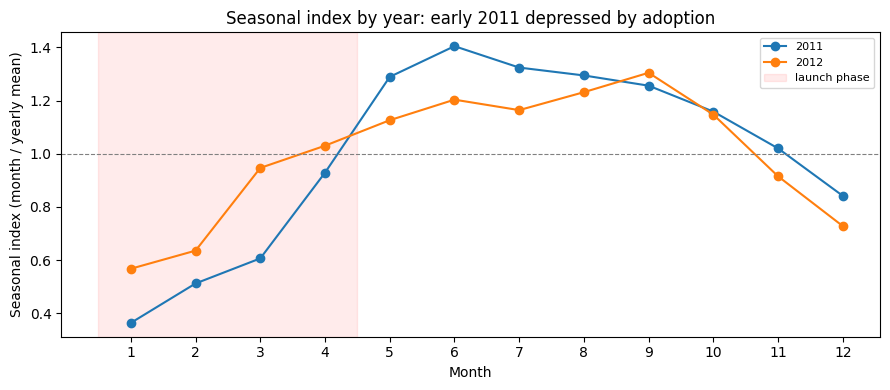

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
months = list(range(1, 13))
ax.plot(months, season_idx[2011], marker="o", label="2011")
ax.plot(months, season_idx[2012], marker="o", label="2012")
ax.axvspan(0.5, boundary + 0.5, color="red", alpha=0.08, label="launch phase")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xticks(months)
ax.set_xlabel("Month")
ax.set_ylabel("Seasonal index (month / yearly mean)")
ax.set_title("Seasonal index by year: early 2011 depressed by adoption")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# Growth on the organic regime: overlapping mature months (after the boundary) of both years.
mature_months = list(range(boundary + 1, 13))
m2011 = pivot.loc[mature_months, 2011].mean()
m2012 = pivot.loc[mature_months, 2012].mean()
mature_growth = (m2012 / m2011 - 1) * 100

print(f"Headline growth (full period):                          +{growth_pct:.0f}%")
print(f"Organic growth (months {mature_months[0]}–12, both mature): +{mature_growth:.0f}%")
print("\nThe difference = the launch phase's contribution to the headline number.")

Headline growth (full period):                          +65%
Organic growth (months 5–12, both mature): +52%

The difference = the launch phase's contribution to the headline number.


### Observations

- **The launch phase is roughly January–April 2011, the organic regime starts in May 2011** (from that month the 2011 index stops being below 2012). The early months are depressed not by season but by the slow build-up of users at the start.
- **So the headline +65% is inflated by the launch.** On the mature months of both years growth is more modest (+52%) — that is the "real" organic rate.

**What this changes:** the launch phase is a one-time effect that will not repeat. We keep the `days_since_launch` feature (the tree will catch the break), but the launch rows themselves are a candidate to drop from training (we will decide by experiment). The early-2011 holidays (MLK, Washington, Emancipation) are worth re-checking on the organic data (see [holidays](exploration_holidays.ipynb)).

## 4. Weekday and weekend

---

On regular days (without holidays): does demand depend on the weekday? We look at two levels — daily volume and the within-day profile.

There is almost no distortion here: each weekday occurs ~100 times, evenly across the whole period, so growth and season cancel out on average — we can use raw means (unlike for holidays).

Mean daily rentals by weekday (regular days):
       mean     std  count
Mon  4399.0  1750.0     90
Tue  4545.0  1803.0    103
Wed  4521.0  2028.0    103
Thu  4720.0  1919.0    102
Fri  4719.0  1882.0    102
Sat  4551.0  2197.0    105
Sun  4229.0  1872.0    105

Weekdays: 4,585   weekends: 4,390   difference: -4.3%


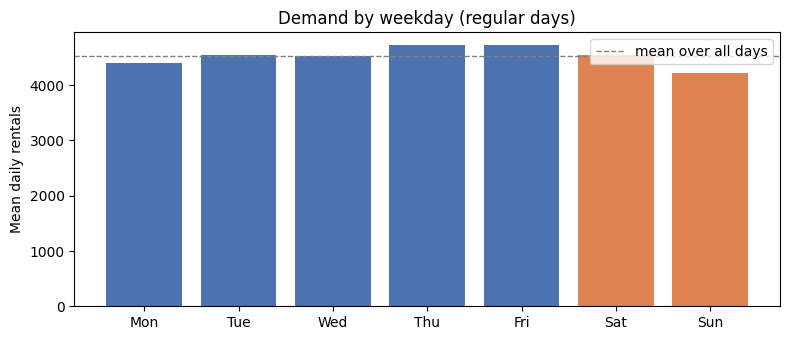

In [10]:
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

by_dow = regular.groupby("day_of_week")["daily_rentals"].agg(["mean", "std", "count"]).round(0)
by_dow.index = [dow_names[i] for i in by_dow.index]

weekday_mean = regular[regular["day_of_week"] < 5]["daily_rentals"].mean()
weekend_mean = regular[regular["day_of_week"] >= 5]["daily_rentals"].mean()

print("Mean daily rentals by weekday (regular days):")
print(by_dow.to_string())
print(f"\nWeekdays: {weekday_mean:,.0f}   weekends: {weekend_mean:,.0f}   "
      f"difference: {(weekend_mean / weekday_mean - 1) * 100:+.1f}%")

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#4c72b0"] * 5 + ["#dd8452"] * 2
ax.bar(by_dow.index, by_dow["mean"], color=colors)
ax.axhline(regular["daily_rentals"].mean(), color="grey", linestyle="--", linewidth=1,
           label="mean over all days")
ax.set_ylabel("Mean daily rentals"); ax.set_title("Demand by weekday (regular days)")
ax.legend()
plt.tight_layout(); plt.show()

### Observations

- The daily volume **barely depends on the weekday**: Mon–Sun in the range ~4,230–4,720, weekdays vs weekends only **−4.3%**.
- As a *volume* feature `is_weekend` is weak — the total number of rentals per day is about the same.
- But this is about total volume. Equal volume does not mean an equal within-day distribution → we check the hourly profile.

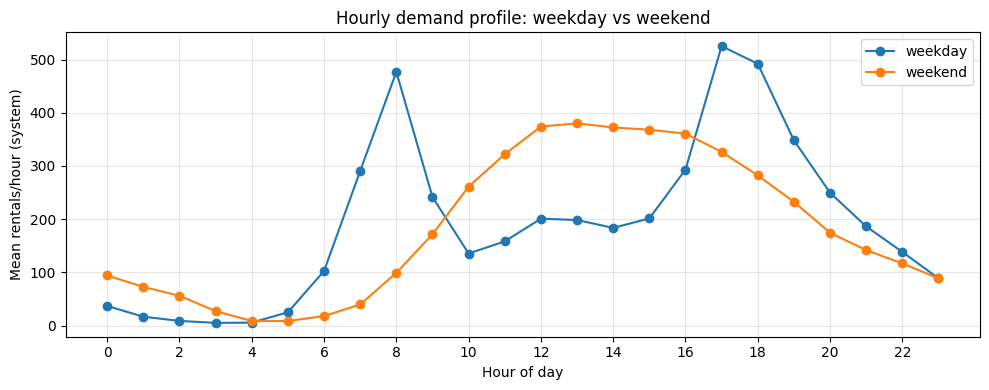

Peak hours — weekday: [17, 18, 8]
Peak hours — weekend: [13, 12, 14]


In [11]:
# System-wide hourly profile from hourly_by_location (summed over locations), regular days.
sys_hourly = fd.groupby("datetime_hourly").agg(
    rentals=("total_rentals", "sum"),
    hour=("hour_of_day", "first"),
    is_weekend=("is_weekend", "first"),
    is_holiday=("is_holiday", "max"),
).reset_index()
sys_hourly = sys_hourly[sys_hourly["is_holiday"] == 0]

profile = sys_hourly.groupby(["is_weekend", "hour"])["rentals"].mean().unstack("is_weekend")
profile.columns = ["weekday", "weekend"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profile.index, profile["weekday"], marker="o", label="weekday")
ax.plot(profile.index, profile["weekend"], marker="o", label="weekend")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day"); ax.set_ylabel("Mean rentals/hour (system)")
ax.set_title("Hourly demand profile: weekday vs weekend"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Peak hours — weekday:", profile["weekday"].sort_values(ascending=False).head(3).index.tolist())
print("Peak hours — weekend:", profile["weekend"].sort_values(ascending=False).head(3).index.tolist())

### Observations

The daily volume is almost the same, but **the within-day shape differs**:

- **Weekdays** — two peaks, like commuting: morning at **8:00** and evening at **17:00–18:00**.
- **Weekends** — one gentle daytime hump at **12:00–14:00** and more active nights (0–2h: ~90 vs ~30 on weekdays — leisure and nightlife).

**Main takeaway:** the weekday affects not the volume but **when people ride** — this is the `is_weekend × hour_of_day` interaction. On its own `is_weekend` changes the daily volume by only ~4%, but it completely rearranges the daily profile.

For the model: this is exactly the structure the linear baseline underestimated (a systematic miss at peak hours, see [eda_and_modeling.ipynb](eda_and_modeling.ipynb)). A linear model needs an explicit `hour × weekend` term; a tree picks it up by itself.

## Conclusions

---

- **Demand is unstable over time:** +65% growth year over year, but it is inflated by the launch phase; the organic rate is **+52%** (§3).
- **Two regimes:** launch (≈ January–April 2011) and organic (from May 2011). The launch is a one-time user build-up.
- **Trend feature — `days_since_launch`, not `year`:** it captures both the between-year shift and the gradual rise within 2011 (for a linear model this is a slope, not a step). For 2013+ the model does not extrapolate (a tree hits a "wall"). We keep the launch rows in mind as a candidate to drop (by experiment).
- **Split — chronological** (both years in train and test), not train=2011 / test=2012 — otherwise the metrics measure growth, not the quality of the patterns.
- **For a linear model:** growth is multiplicative, so a log target is worth considering.
- **Weekday** affects not the volume (weekdays vs weekends −4%) but the **shape** of the day: weekdays peak at 8 and 17–18h, weekends hump at 12–14h. The value is in the `is_weekend × hour_of_day` interaction (§4).
- **Holidays:** their spread is mostly explained by service growth; the detailed analysis is in [exploration_holidays.ipynb](exploration_holidays.ipynb).